# License Plate Detection + OCR — Full Pipeline (Raspberry Pi code path)

Run this notebook cell-by-cell with the **License Plate Project (venv)** kernel (kernel picker, top-right in VS Code).

**This notebook runs the exact same code that runs on the Raspberry Pi** — the `license_plate_pipeline.pi` package: YOLO detection via **ONNX Runtime** and OCR via **RapidOCR** (both `onnxruntime`, no PyTorch / PaddlePaddle). So what you confirm here is what deploys. PaddlePaddle has no ARM64 wheel, which is why the Pi uses this ONNX/RapidOCR path — see `PROJECT_CONTEXT.md` and `IMPLEMENTATION_PLAN.md`.

**Steps:**
1. Setup
2. Load the ONNX detection model
3. Detect a plate in an image
4. Crop the detected plate
5. Load the OCR engine (RapidOCR)
6. Read the plate text
7. Final pipeline on one image: detect → read
8. Run the full pipeline on video — detection every frame, OCR only a few frames per **tracked** plate, then dedup. One clean row per truck.
9. Live webcam test — the same engine on a live feed

Full history, roadmap, and environment notes: [`PROJECT_CONTEXT.md`](../PROJECT_CONTEXT.md).

## 1. Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))  # so `import license_plate_pipeline` works from notebooks/

TEST_IMAGES = PROJECT_ROOT / "test_images"
TEST_IMAGE = TEST_IMAGES / "demo2.jpg"  # US plate (California), ground truth 6FVZ747

## 2. Load the ONNX detection model

The YOLO26n model fine-tuned on Colab, exported to ONNX (`models/best.onnx`) and run with ONNX Runtime — the same file and runtime the Pi uses. No PyTorch / ultralytics needed to run inference.

In [2]:
from license_plate_pipeline.pi.detection import get_model

session = get_model()  # onnxruntime InferenceSession from models/best.onnx
inp = session.get_inputs()[0]
print("ONNX detection model loaded. Input:", inp.name, inp.shape)

ONNX detection model loaded. Input: images [1, 3, 640, 640]


## 3. Detect a plate in an image

Detections: 1


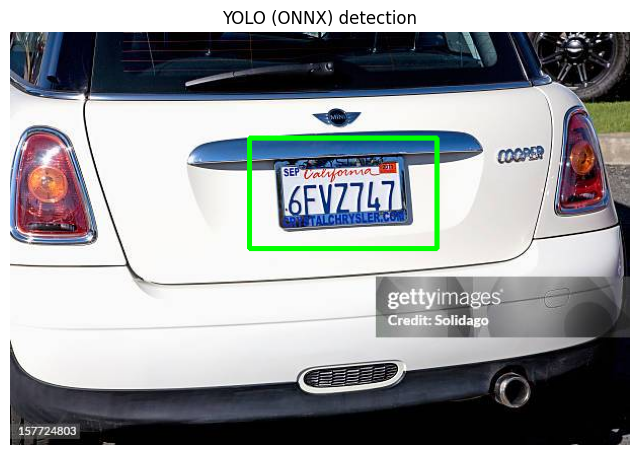

In [4]:
from license_plate_pipeline.pi.detection import detect_boxes

img = cv2.imread(str(TEST_IMAGE))
boxes = detect_boxes(img)
print(f"Detections: {len(boxes)}")

annotated = img.copy()
for x1, y1, x2, y2 in boxes:
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO (ONNX) detection")
plt.show()

## 4. Crop the detected plate

`detect_boxes` already returns the box padded 10% per side. For RapidOCR we feed the crop as-is: the upscale + grayscale + equalize tuning that helped PaddleOCR gave RapidOCR no gain (grayscale actually hurt it), so `preprocess_for_ocr` in the Pi path is a pass-through. See `license_plate_pipeline/pi/ocr.py` for the measured reasoning.

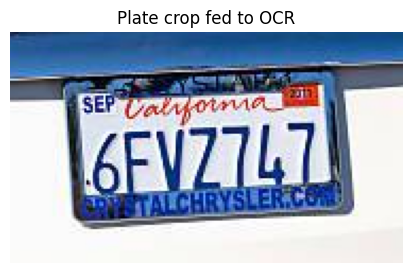

In [5]:
from license_plate_pipeline.pi.ocr import preprocess_for_ocr

x1, y1, x2, y2 = boxes[0]  # detect_boxes already padded this box
crop = img[y1:y2, x1:x2]
processed = preprocess_for_ocr(crop)  # identity for the RapidOCR path

plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.title("Plate crop fed to OCR")
plt.axis("off")
plt.show()

## 5. Load the OCR engine (RapidOCR)

RapidOCR runs the PP-OCR model family on ONNX Runtime — the same engine as the Pi, and it installs on ARM64 (PaddleOCR / PaddlePaddle can't). Runs on CPU here; actual Pi speed will differ.

In [6]:
from license_plate_pipeline.pi.ocr import get_reader

reader = get_reader()  # RapidOCR (onnxruntime)
print("OCR engine loaded (RapidOCR).")

OCR engine loaded (RapidOCR).


## 6. Read the plate text

In [7]:
from license_plate_pipeline.pi.ocr import read_crop

for text, confidence in read_crop(crop):
    print(f"'{text}' (confidence: {confidence:.2f})")

'SEP7' (confidence: 0.96)
'Valrforrna' (confidence: 0.71)
'2017' (confidence: 0.76)
'6FVZ747' (confidence: 0.98)
'STALCHRYSLER.COM' (confidence: 0.95)


## 7. Final pipeline on one image: detect → read

The single-image entry point from the Pi package (`license_plate_pipeline.pi.pipeline.read_plates_from_image`) — detect every plate, crop, OCR, return the plate-like text. Same detect + read used on video next.

In [8]:
from license_plate_pipeline.pi.pipeline import read_plates_from_image

for text, confidence in read_plates_from_image(TEST_IMAGE):
    print(f"Detected plate text: '{text}' (confidence: {confidence:.2f})")

Detected plate text: '6FVZ747' (confidence: 0.98)


## 8. Run the full pipeline on video

`process_video` (from `license_plate_pipeline.pi.pipeline`) is what the Pi uses to log trucks. Each frame it runs cheap YOLO detection, **tracks** every plate's box across frames (IOU matching), and runs the expensive OCR only a few times per *physical* plate — not every frame. That single change took this clip from ~1170s to ~100s. It then dedups (merges OCR flicker, absorbs partial reads) and returns one clean row per truck: plate text, first/last seen, frame count, best confidence.

`demo.mp4` is ~21s; expect roughly a minute or two on this CPU. (The tracking + dedup that used to be shown as separate manual steps now all live inside this one call — see `license_plate_pipeline/tracking.py` and `dedup.py`.)

In [ ]:
from license_plate_pipeline.pi.pipeline import process_video

video_path = TEST_IMAGES / "demo.mp4"
events = process_video(video_path)
print(f"Final deduped events: {len(events)}")

In [ ]:
import pandas as pd

df = pd.DataFrame(events).sort_values("first_seen").reset_index(drop=True)
df["seconds_first"] = df["first_seen"].round(2)
df["seconds_last"] = df["last_seen"].round(2)
df[["plate_text", "seconds_first", "seconds_last", "frame_count", "best_confidence"]]

In [ ]:
# Verify the tracking/dedup decisions: which raw OCR reads merged into each event.
for e in sorted(events, key=lambda ev: ev["first_seen"]):
    reads = ", ".join(f"'{t}' ({c:.2f})" for t, c, _fc in e["readings"])
    print(f"-> '{e['plate_text']}' (best {e['best_confidence']:.2f}): {reads}")

## 9. Live webcam test — with data cleaning

Runs the **full tracked + deduplicated + validated pipeline** live on your webcam — the same code as the video table (section 8) and the Pi's `run_live.py`, **not** raw per-frame reads. Detection runs every frame (you see the boxes live), but each plate is **tracked** across frames and OCR'd only a few times, then emitted as **one clean, deduplicated event** the moment the vehicle leaves the frame.

**Run the Setup cell (section 1) first**, then run the next cell.

- Set `CAMERA_INDEX = 0` for a built-in laptop webcam, `1` for an external USB camera.
- A window opens showing the live feed with detected plates boxed.
- **Hold a plate up, then take it away** — a few seconds later its single clean row prints below (it commits when the plate leaves view, so it captures the full sighting and picks the best read).
- Press **`q`** in the window to stop. The next cell builds the results table.

Why this matters: with raw per-frame reads, one plate held for a few seconds prints a dozen duplicate lines (e.g. `PGV9359` ×5). Here that becomes a **single clean row** — same cleaning as the video.

In [ ]:
import time

from license_plate_pipeline.pi.pipeline import process_camera

CAMERA_INDEX = 0  # 0 = built-in laptop webcam, 1 = external USB camera
PREVIEW_SCALE = 0.6  # shrink the preview window (display only); 1.0 = full size

# process_camera runs the SAME tracked + deduped + validated pipeline as the
# video (section 8) and the Pi (run_live.py): detection every frame, OCR only a
# few times per tracked vehicle, then ONE clean event per vehicle - emitted the
# moment it leaves the frame. The preview still shows live boxes every frame.

_stop = {"flag": False}


def show(frame, boxes):
    for x1, y1, x2, y2 in boxes:
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Display-only shrink (detection/OCR ran on the full real frame already).
    view = cv2.resize(frame, None, fx=PREVIEW_SCALE, fy=PREVIEW_SCALE)
    cv2.imshow("Live webcam - press 'q' to stop", view)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        _stop["flag"] = True


print("Webcam open. Hold a plate up, then TAKE IT AWAY to log one clean row. Press 'q' to stop.")

clean_events = []
try:
    for event in process_camera(camera_index=CAMERA_INDEX, on_frame=show, stop=lambda: _stop["flag"]):
        clean_events.append(event)
        t = time.strftime("%H:%M:%S", time.localtime(event["timestamp"]))
        print(f"[{t}] {event['plate_text']}  (confidence {event['best_confidence']:.2f}, seen in {event['frame_count']} frames)")
finally:
    cv2.destroyAllWindows()

print(f"\nStopped. {len(clean_events)} clean vehicle events (deduplicated).")

In [ ]:
import pandas as pd
from IPython.display import display

if clean_events:
    df = pd.DataFrame(clean_events).sort_values("first_seen").reset_index(drop=True)
    df["time"] = pd.to_datetime(df["timestamp"], unit="s").dt.strftime("%H:%M:%S")
    display(df[["time", "plate_text", "best_confidence", "frame_count"]])
else:
    print("No clean events yet - run the cell above, hold a plate up, then remove it so a row commits.")

## What's next

This notebook now runs the exact Pi code path end to end. Once the live webcam test (step 9) reads plates cleanly, the next step is running it on the actual Raspberry Pi — follow [`PI_SETUP.md`](../PI_SETUP.md). Project status and roadmap live in [`PROJECT_CONTEXT.md`](../PROJECT_CONTEXT.md).